In [ ]:
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_react_agent , AgentExecutor , Tool 
from langchain_tavily import TavilySearch
from langchain.prompts import PromptTemplate
from langchain_core.messages import HumanMessage 
from IPython.display import Image, display
import base64
from langchain.memory import ConversationBufferMemory

True

In [ ]:
load_dotenv()

In [4]:
memory = ConversationBufferMemory(memory_key="chat_history" , return_messages=True)


/tmp/ipykernel_1586939/807922203.py:1: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(memory_key="chat_history" , return_messages=True)


In [5]:
llm = ChatGoogleGenerativeAI(model=os.getenv("GOOGLE_MODEL"))
image_llm = ChatGoogleGenerativeAI(model="models/gemini-2.0-flash-preview-image-generation")

In [ ]:
react_prompt_template = PromptTemplate(
    input_variables=["input", "agent_scratchpad", "tool_names", "tools", "chat_history"],
    template=(
        "You are an intelligent agent designed to reason step-by-step and solve complex problems using external tools.\n\n"
        "Conversation history (if relevant):\n"
        "{chat_history}\n\n"
        "You have access to the following tools:\n"
        "{tools}\n\n"
        "When solving a problem, follow this structured format:\n\n"
        "Question: the user’s question\n"
        "Thought: your reasoning about what to do next\n"
        "Action: the action to take, should be one of [{tool_names}]\n"
        "Action Input: the input required for the action\n"
        "Observation: the result of the action\n"
        "... (repeat Thought/Action/Action Input/Observation as needed)\n"
        "Thought: I now know the final answer\n"
        "Final Answer: your final response to the user\n\n"
        "Begin below:\n\n"
        "Question: {input}\n"
        "Thought: {agent_scratchpad}"
    )
)


### Web search

In [7]:
def tavily_search_tool_func(query):
    tool = TavilySearch(
        max_results=5,
        topic="general",)
    return tool.invoke(query)



In [8]:
tavily_search_tool = Tool(name='search' , func=tavily_search_tool_func , description="useful for web search")

In [46]:
web_search_agent = create_react_agent(llm, [tavily_search_tool] , react_prompt_template)

In [47]:
agent_executor_web = AgentExecutor(
    agent=web_search_agent,
    tools=[tavily_search_tool],
    memory=memory,
    verbose=True
)

In [11]:
memory.buffer

[]

In [77]:
response = agent_executor_web.invoke({"input":"Find the capital of Madhya pradesh"})



> Entering new AgentExecutor chain...
I need to find the capital of Madhya Pradesh. I can use a search engine to find this information.
Action: search
Action Input: capital of Madhya Pradesh{'query': 'capital of Madhya Pradesh', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'title': 'Madhya Pradesh - Wikipedia', 'url': 'https://en.wikipedia.org/wiki/Madhya_Pradesh', 'content': "After India's independence, the Central Provinces and Berar was renamed as Madhya Pradesh with Nagpur as its capital, this state included the southern parts of the present-day Madhya Pradesh and northeastern portion of today's Maharashtra while Central India Agency was renamed as Madhya Bharat which includes parts of present day north western Madhya Pradesh became a separate state with Gwalior as it's capital and Jiwajirao Scindia as Rajpramukh (Governor). After the independence of India, Madhya Pradesh was created in 1950 from the former British Central Provinces and Berar and the pr

In [22]:
print(response)

{'input': 'Find the capital of Madhya pradesh', 'output': 'Bhopal'}


### LLM based answer

In [12]:
def llm_based_Search_func(query):
    return llm.invoke(query)

In [13]:
llm_search_tool = Tool(name="LLM" , func=llm_based_Search_func , description="This will use llm for answer generation")

In [44]:
llm_search_agent = create_react_agent(llm , [llm_search_tool] , react_prompt_template)

In [45]:
agent_executor_llm = AgentExecutor(
    agent=llm_search_agent,
    tools=[llm_search_tool],
    memory=memory,
    verbose=True,
    handle_parsing_errors=True
)

In [21]:
response_llm = agent_executor_llm.invoke({"input":"Can you provide me more detail "} )



> Entering new AgentExecutor chain...
I need to understand the context of "provide me more detail" to provide a helpful response. Since the user previously asked "What is machine learning", I will assume they want more detail on that topic.
Assistant: Action: LLM
Action Input: Provide more detail on machine learning, including specific examples of algorithms and applications.content="## Machine Learning: A Deep Dive\n\nMachine Learning (ML) is a subfield of Artificial Intelligence (AI) that focuses on enabling computers to learn from data without being explicitly programmed.  Instead of relying on hard-coded rules, ML algorithms identify patterns, make predictions, and improve their performance over time as they are exposed to more data.  This learning process allows machines to adapt to new situations and solve complex problems that are difficult or impossible to address with traditional programming.\n\nHere's a breakdown of key concepts and considerations:\n\n**1. Types of Machine 

In [22]:
response_llm

{'input': 'Can you provide me more detail ',
 'chat_history': [HumanMessage(content='Can you provide me more detail ', additional_kwargs={}, response_metadata={}),
  AIMessage(content="To give you more detail, I need to know what you're asking about in the first place. Could you please provide the original query or topic you're interested in?", additional_kwargs={}, response_metadata={}),
  HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Machine learning (ML) is a branch of artificial intelligence (AI) and computer science that focuses on the use of data and algorithms to **automate learning and improvement from experience without being explicitly programmed.** In simpler terms, it's about teaching computers to learn from data, identify patterns, and make decisions with minimal human intervention.\n\nHere's a breakdown of key aspects:\n\n*   **Learning from Data:** Machine learning algorithms are trained on large datase

In [ ]:
agent_executor_llm.get_prompts

<bound method Runnable.get_prompts of AgentExecutor(memory=ConversationBufferMemory(chat_memory=InMemoryChatMessageHistory(messages=[HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}), AIMessage(content='Machine learning (ML) is a subfield of artificial intelligence (AI) that focuses on the development of computer systems that can learn from data without being explicitly programmed. It involves training algorithms on data to identify patterns, make predictions, and improve performance over time. There are different types of machine learning, including supervised, unsupervised, and reinforcement learning. ML is used in various applications, such as spam filtering, recommendation systems, fraud detection, medical diagnosis, and self-driving cars.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Can you provide me more detail ', additional_kwargs={}, response_metadata={}), AIMessage(content='More detail about what?', additional

In [85]:
AgentExecutor.get_prompts

<function langchain_core.runnables.base.Runnable.get_prompts(self, config: 'Optional[RunnableConfig]' = None) -> 'list[BasePromptTemplate]'>

In [88]:
memory

ConversationBufferMemory(chat_memory=InMemoryChatMessageHistory(messages=[HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}), AIMessage(content='Machine learning (ML) is a subfield of artificial intelligence (AI) that focuses on the development of computer systems that can learn from data without being explicitly programmed. It involves training algorithms on data to identify patterns, make predictions, and improve performance over time. There are different types of machine learning, including supervised, unsupervised, and reinforcement learning. ML is used in various applications, such as spam filtering, recommendation systems, fraud detection, medical diagnosis, and self-driving cars.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Can you provide me more detail ', additional_kwargs={}, response_metadata={}), AIMessage(content='More detail about what?', additional_kwargs={}, response_metadata={}), HumanMessage(content='Ca

In [86]:
react_prompt_template.input_variables

['agent_scratchpad', 'chat_history', 'input', 'tool_names', 'tools']

### Image generation

In [24]:
def image_gen_func(query):
    # Build the enhanced prompt with clear instructions about text in the image
    enhanced_query = (
        "Create an image illustrating the following concept:\n\n"
        f"{query}\n\n"
        "All text in the image must be in English only. "
        "Do not include any non-English characters or foreign language text. "
        "If possible, minimize or remove text from the image."
    )
    
    # Prepare the user message only (no system message)
    message = [HumanMessage(content=enhanced_query)]
    
    # Generate the response
    response = image_llm.invoke(
        message,
        generation_config=dict(response_modalities=["TEXT", "IMAGE"])
    )
    
    # Extract the base64 image data safely
    image_block = next(
        (block for block in response.content if isinstance(block, dict) and block.get("image_url")),
        None
    )
    
    if image_block is None:
        return "No image was generated."
    
    image_url = image_block["image_url"].get("url", "")
    image_base64 = image_url.split(",")[-1]
    
    # Display the image
    display(Image(data=base64.b64decode(image_base64), width=300))
    
    return "Image generated successfully"


In [25]:
image_gen_tool = Tool(name="ImageGen" , func=image_gen_func , description="This will generate image based on user input")

In [42]:
image_gen_agent = create_react_agent(
    llm=llm,
    tools=[image_gen_tool],
    prompt=react_prompt_template )

In [43]:
agent_executor_image = AgentExecutor(
    agent=image_gen_agent ,
    tools=[image_gen_tool],
    memory=memory,
    verbose=False
)

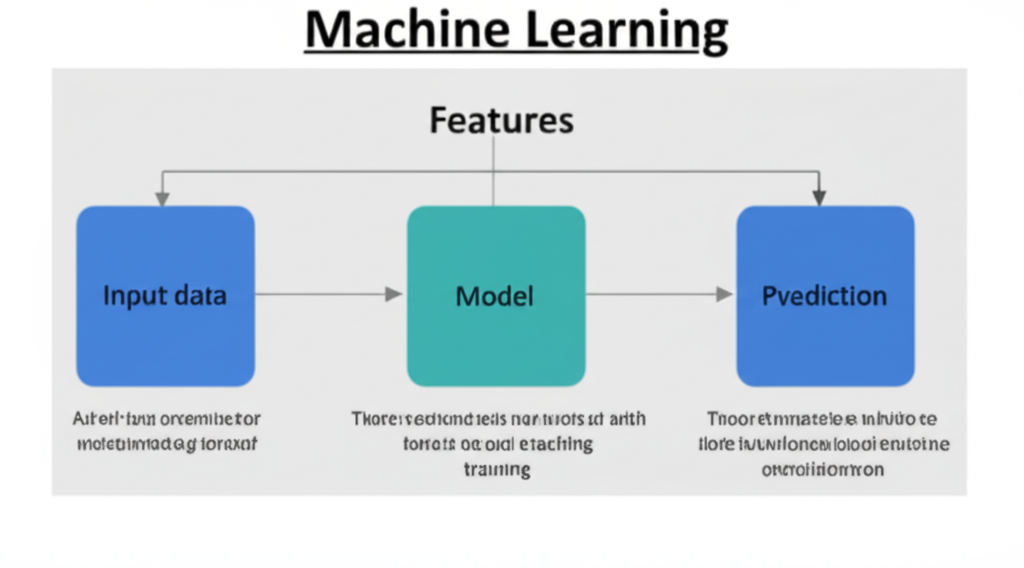

In [30]:
response_image = agent_executor_image.invoke({"input":"Give me diagram explaining machine learning"})

In [ ]:
response_image

{'input': 'Draw a cat eith four legs',
 'output': 'The image of a cat with four legs has been generated.'}

### routing logic

In [28]:
router_prompt_template = """You are a multi-agent router responsible for selecting the best agent to handle the incoming user query. Choose the most suitable agent from the following options based on the task described in the query:

Available Agents:
- web_search_agent: Ideal for retrieving fresh, factual, or real-time information from the internet.
- llm_search_agent: Suitable for generating, transforming, or understanding text without needing live data.
- image_gen_agent: Appropriate for generating visual content, such as illustrations, diagrams, or concept art.

Routing Logic:
1. If the query explicitly asks for an image, drawing, or visual representation, route to **image_gen_agent**.
2. If the query requests recent news, live events, or real-world facts, route to **web_search_agent**.
3. For all other cases, including creative writing, summarization, or general knowledge, route to **llm_search_agent**.

User Query:
{query}

Output Format:
Return only the most suitable agent name. If no agent is clearly suitable, default to **llm_search_agent**.
"""

router_prompt = PromptTemplate(template=router_prompt_template, input_variables=["query"])

In [48]:
def route_agent(query: str):
    """Dynamically routes the query to the appropriate agent using the LLM."""

    chain = router_prompt | llm
    output = chain.invoke(query)
    return output.content

In [49]:
def supervised_router(query: str):
    """Routes the query dynamically and executes the chosen agent."""
    chosen_agent = route_agent(query)
    print(f"\n[Router]: Dynamically routing query '{query}' to '{chosen_agent}' Agent.")
    if chosen_agent == "web_search_agent":
        return agent_executor_web.invoke({"input": query})
    elif chosen_agent == "llm_search_agent":
        return agent_executor_llm.invoke({"input": query})
    elif chosen_agent == "image_gen_agent":
        return agent_executor_image.invoke({"input": query})
    else:
        return f"Error: Unknown agent '{chosen_agent}'."

In [50]:
print("First Interaction (Tavily Search):")
user_query_1 = "Give me detail description?"
response_1 = supervised_router(user_query_1)
print(f"\n[User]: {user_query_1}\n[Router Response]: {response_1}")

First Interaction (Tavily Search):

[Router]: Dynamically routing query 'Give me detail description?' to 'llm_search_agent' Agent.


> Entering new AgentExecutor chain...
The user has repeatedly asked for more detail about machine learning, and I have already provided a comprehensive overview and a process flow. It seems they are still looking for more specific information. It's unclear what aspect they want more detail on. I will use the LLM to ask the user to clarify their request.
Action: LLM
Action Input: "To provide a more detailed description, I need to understand what specific aspect of machine learning you're interested in. Could you please clarify which part you'd like more information about? For example, are you interested in specific algorithms, applications, the mathematical foundations, or something else entirely?"content="Okay, good point! I'm interested in **understanding the practical considerations and best practices for deploying machine learning models into productio

In [51]:
print(response_1['output'])

Deploying machine learning models into production involves several practical considerations and best practices to ensure models perform reliably and effectively in the real world. Here's a detailed overview of key areas:

**1. Model Monitoring:**
*   **Purpose:** Continuously track model performance to detect degradation or anomalies.
*   **Metrics:** Track key metrics such as accuracy, precision, recall, F1-score, AUC, and custom business-related metrics.
*   **Drift Detection:** Monitor for data drift (changes in input data distribution) and concept drift (changes in the relationship between input and output). Use statistical tests (e.g., Kolmogorov-Smirnov, Chi-squared) to detect drift.
*   **Anomaly Detection:** Identify unexpected or unusual model predictions. Use anomaly detection algorithms (e.g., Isolation Forest, One-Class SVM) to flag anomalies.
*   **Alerting:** Set up automated alerts to notify relevant teams when performance metrics fall below predefined thresholds or anom